# Task 2 - Unemployment Analysis with Python

This notebook studies unemployment trends in India, especially before and after the COVID-19 period. The code first looks for a local CSV in the data folder, then tries a public dataset URL so the notebook is easier to run on another machine.

In [1]:
import os
from io import BytesIO
from pathlib import Path
from zipfile import ZipFile

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## Load the dataset

Expected local file names: data/Unemployment in India.csv, data/Unemployment_Rate_upto_11_2020.csv, or data/unemployment.csv.

In [2]:
data_dir = Path.cwd() / 'data'
if not data_dir.is_dir():
    data_dir = Path.cwd().parent / 'data'

candidate_files = [
    data_dir / 'Unemployment in India.csv',
    data_dir / 'Unemployment_Rate_upto_11_2020.csv',
    data_dir / 'unemployment.csv'
]

source = next((file for file in candidate_files if file.is_file()), None)

if source is not None:
    df = pd.read_csv(source)
else:
    dataset_url = 'https://www.kaggle.com/api/v1/datasets/download/gokulrajkmv/unemployment-in-india'
    try:
        response = requests.get(dataset_url, timeout=30)
        response.raise_for_status()
        with ZipFile(BytesIO(response.content)) as archive:
            csv_name = next(name for name in archive.namelist() if name.endswith('Unemployment_Rate_upto_11_2020.csv'))
            with archive.open(csv_name) as csv_file:
                df = pd.read_csv(csv_file)
        source = f'{dataset_url} ({csv_name})'
    except (requests.RequestException, OSError, StopIteration) as error:
        raise FileNotFoundError(
            'Dataset not found locally and the online download failed. '
            'Add Unemployment_Rate_upto_11_2020.csv to the data folder and run this cell again.'
        ) from error

print('Loaded from:', source)
df.head()

Loaded from: c:\Users\Angad\OIBSIP\data\Unemployment_Rate_upto_11_2020.csv


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
df.columns = [col.strip().replace(' ', '_') for col in df.columns]
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated_Unemployment_Rate_(%)',
       'Estimated_Employed', 'Estimated_Labour_Participation_Rate_(%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')

In [4]:
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum())

df.head()

Shape: (267, 9)

Data types:
Region                                         str
Date                                           str
Frequency                                      str
Estimated_Unemployment_Rate_(%)            float64
Estimated_Employed                           int64
Estimated_Labour_Participation_Rate_(%)    float64
Region.1                                       str
longitude                                  float64
latitude                                   float64
dtype: object

Missing values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated_Unemployment_Rate_(%)            0
Estimated_Employed                         0
Estimated_Labour_Participation_Rate_(%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


,Region,Date,Frequency,Estimated_Unemployment_Rate_(%),Estimated_Employed,Estimated_Labour_Participation_Rate_(%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## Clean column names and dates

In [5]:
rename_map = {
    'Region': 'region',
    'Date': 'date',
    'Frequency': 'frequency',
    'Estimated_Unemployment_Rate_(%)': 'unemployment_rate',
    'Estimated_Employed': 'estimated_employed',
    'Estimated_Labour_Participation_Rate_(%)': 'labour_participation_rate',
    'Area': 'area',
    'Region.1': 'zone',
    'Longitude': 'longitude',
    'Latitude': 'latitude'
}

df = df.rename(columns={old: new for old, new in rename_map.items() if old in df.columns})
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

for col in ['unemployment_rate', 'estimated_employed', 'labour_participation_rate']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['date', 'region', 'unemployment_rate']).copy()
df[['region', 'date', 'unemployment_rate']].head()

,region,date,unemployment_rate
0,Andhra Pradesh,2020-01-31,5.48
1,Andhra Pradesh,2020-02-29,5.83
2,Andhra Pradesh,2020-03-31,5.79
3,Andhra Pradesh,2020-04-30,20.51
4,Andhra Pradesh,2020-05-31,17.43


## Region-wise average unemployment

C:\Users\Angad\AppData\Local\Temp\ipykernel_8724\3583936730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_avg.head(10), x='unemployment_rate', y='region', palette='Reds_r')


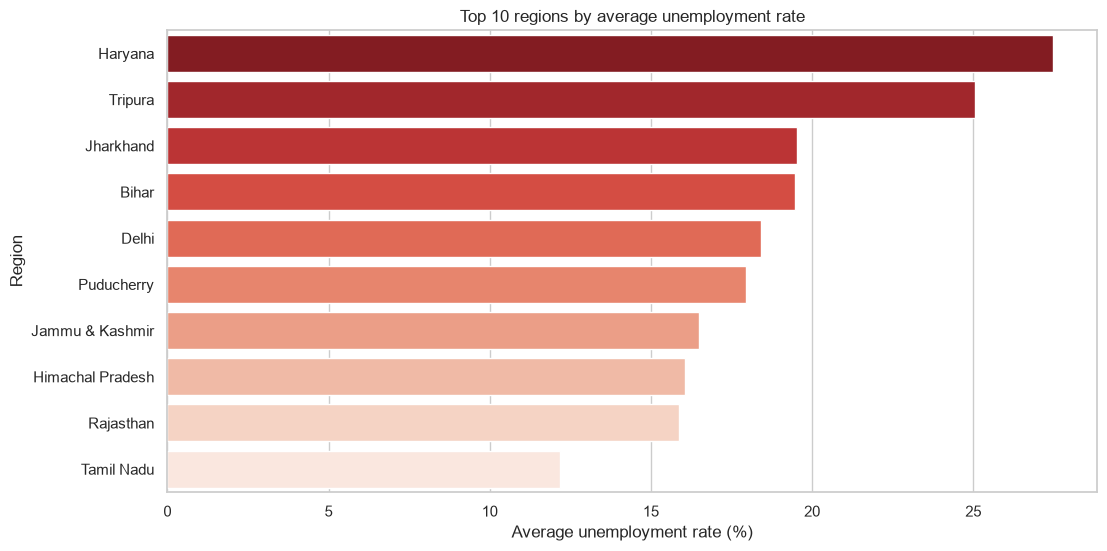

,region,unemployment_rate
7,Haryana,27.477000
23,Tripura,25.055000
10,Jharkhand,19.539000
2,Bihar,19.471000
4,Delhi,18.414000
17,Puducherry,17.942000
9,Jammu & Kashmir,16.477778
8,Himachal Pradesh,16.065000
19,Rajasthan,15.868000
21,Tamil Nadu,12.187000


In [6]:
region_avg = df.groupby('region', as_index=False)['unemployment_rate'].mean()
region_avg = region_avg.sort_values('unemployment_rate', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=region_avg.head(10), x='unemployment_rate', y='region', palette='Reds_r')
plt.title('Top 10 regions by average unemployment rate')
plt.xlabel('Average unemployment rate (%)')
plt.ylabel('Region')
plt.show()

region_avg.head(10)

The bar chart highlights the regions where unemployment stayed highest on average across the available period.

## Month-wise trend

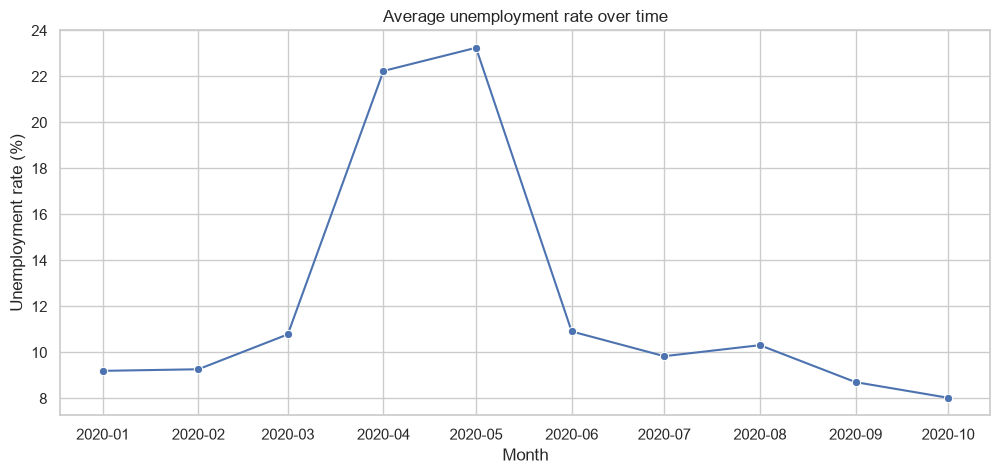

In [7]:
monthly = df.groupby(pd.Grouper(key='date', freq='MS'))['unemployment_rate'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x='date', y='unemployment_rate', marker='o')
plt.title('Average unemployment rate over time')
plt.xlabel('Month')
plt.ylabel('Unemployment rate (%)')
plt.show()

A visible spike around 2020 usually appears in this dataset, matching the disruption caused by COVID-19 restrictions.

## Time-series for selected major regions

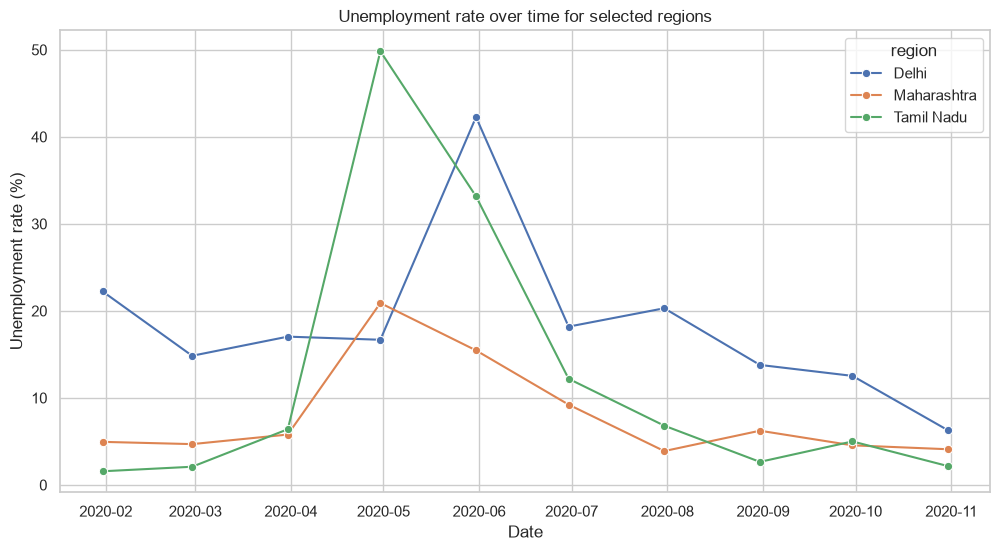

['Maharashtra', 'Delhi', 'Tamil Nadu']

In [8]:
preferred_regions = ['Maharashtra', 'Delhi', 'Tamil Nadu', 'Karnataka', 'Uttar Pradesh']
available_regions = [r for r in preferred_regions if r in df['region'].unique()]
selected_regions = available_regions[:3] if len(available_regions) >= 3 else df['region'].value_counts().head(3).index.tolist()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df[df['region'].isin(selected_regions)], x='date', y='unemployment_rate', hue='region', marker='o')
plt.title('Unemployment rate over time for selected regions')
plt.xlabel('Date')
plt.ylabel('Unemployment rate (%)')
plt.show()

selected_regions

Comparing multiple states makes it easier to see that the pandemic shock did not affect every region equally.

## Correlation heatmap

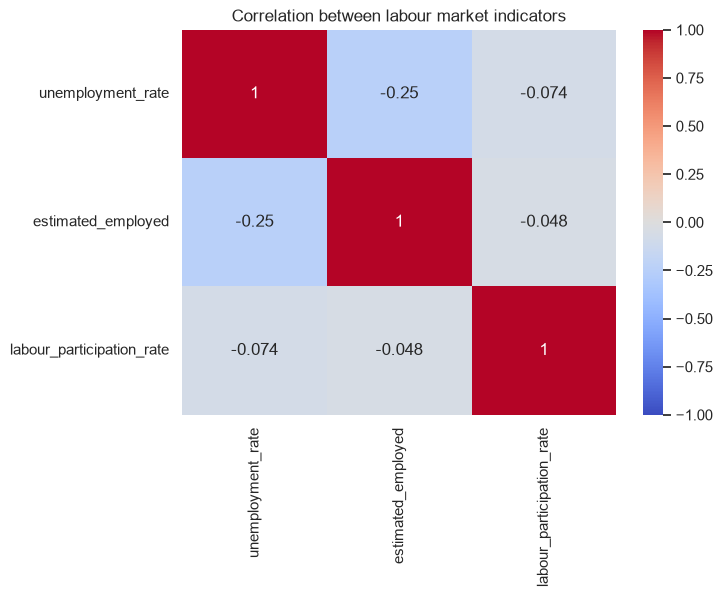

In [9]:
numeric_cols = [col for col in ['unemployment_rate', 'estimated_employed', 'labour_participation_rate'] if col in df.columns]

plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between labour market indicators')
plt.show()

The heatmap shows whether unemployment moves together with labour participation or employment levels in the available data.

## Pre-COVID vs post-COVID comparison

In [10]:
cutoff = pd.Timestamp('2020-03-01')
df['period'] = np.where(df['date'] < cutoff, 'Pre-COVID', 'Post-COVID')

period_summary = df.groupby('period')['unemployment_rate'].agg(['count', 'mean', 'median']).reset_index()
period_summary

,period,count,mean,median
0,Post-COVID,215,12.963860,10.11
1,Pre-COVID,52,9.231346,6.66


C:\Users\Angad\AppData\Local\Temp\ipykernel_8724\1548178505.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=period_summary, x='period', y='mean', palette='Set2')


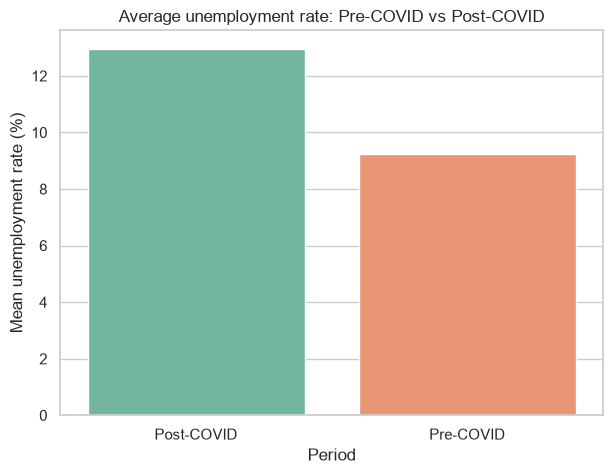

In [11]:
plt.figure(figsize=(7, 5))
sns.barplot(data=period_summary, x='period', y='mean', palette='Set2')
plt.title('Average unemployment rate: Pre-COVID vs Post-COVID')
plt.ylabel('Mean unemployment rate (%)')
plt.xlabel('Period')
plt.show()

## Observations

The post-COVID average is generally higher in this dataset, which supports the idea that the pandemic had a strong labour-market impact. The exact size of the change depends on the regions and months included in the dataset.